In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,precision_score,recall_score,confusion_matrix,accuracy_score

In [2]:
df=pd.read_csv('social_network_ads.csv')

In [3]:
df.shape

(400, 5)

In [4]:
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [6]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [7]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df=df.drop_duplicates()

In [10]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

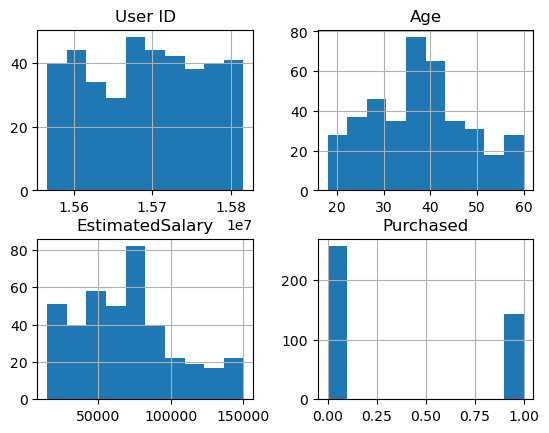

In [11]:
df.hist()
plt.show()

In [12]:
df=df.drop(columns=['User ID'])

In [13]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


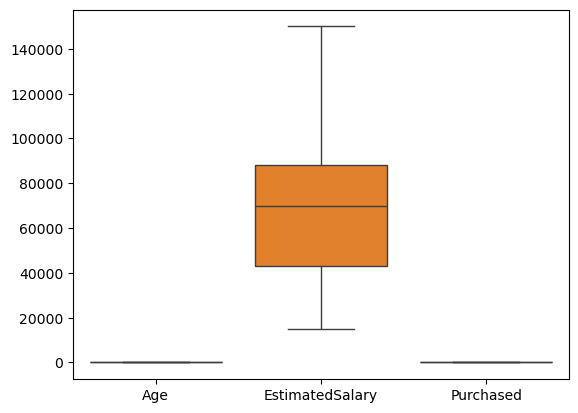

In [14]:
sns.boxplot(data=df)
plt.show()

In [15]:
df['Gender'].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

In [16]:
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])

In [17]:
df['Gender'].value_counts()

Gender
0    204
1    196
Name: count, dtype: int64

<Axes: >

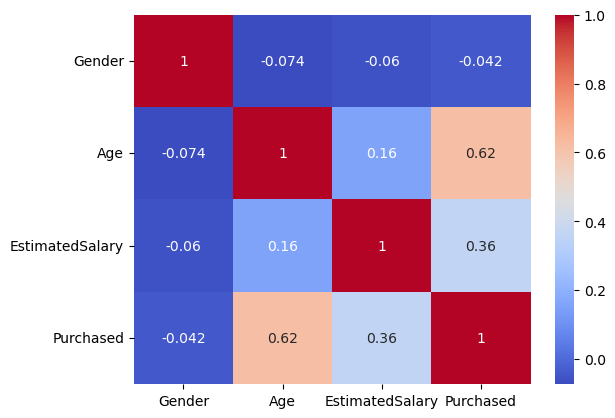

In [18]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

In [19]:
x=df.drop(columns=['Purchased'])
y=df['Purchased']

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [21]:
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)
x_test_scaled=ss.transform(x_test)

In [22]:
model=LogisticRegression()
model.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
y_pred=model.predict(x_test_scaled)

In [24]:
cm=confusion_matrix(y_test,y_pred)

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("True Positive:", TP)
print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)

True Positive: 17
True Negative: 56
False Positive: 2
False Negative: 5


In [25]:
# Total observations
total = TP + TN + FP + FN

# Accuracy
accuracy = (TP + TN) / total

# Error Rate
error_rate = (FP + FN) / total
#OR
#error_rate = 1 - accuracy

# Precision
precision = TP / (TP + FP)

# Recall
recall = TP / (TP + FN)

print("Accuracy:", (accuracy))
print("Error Rate:", (error_rate))
print("Precision:", (precision))
print("Recall:", (recall))

Accuracy: 0.9125
Error Rate: 0.0875
Precision: 0.8947368421052632
Recall: 0.7727272727272727


In [26]:
f1_score(y_test,y_pred)

0.8292682926829268

In [27]:
accuracy_score(y_test,y_pred)

0.9125

In [28]:
precision_score(y_test,y_pred)

0.8947368421052632

In [29]:
1-accuracy_score(y_test,y_pred)

0.08750000000000002

In [30]:
recall_score(y_test,y_pred)

0.7727272727272727

In [35]:
sample_input = [[
    0,      # Gender
    42,     # Age
    75000   # EstimatedSalary
]]
sample_input = ss.transform(sample_input)

prediction = model.predict(sample_input)

print("Prediction:", prediction[0])

Prediction: 0


/usr/lib/python3/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
